In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

# A/B Testing #
## Comparing Two Samples

Question: Do the two sets of values come from the
same underlying distribution?


In [2]:
births = Table.read_table('baby.csv')

In [3]:
# This data was collected at a time when smoking was not known to cause problems during pregnancy.
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [4]:
# Create a table that only shows whether the mother smoked or not and the weight of the newborn. 

smoking_and_birthweight = births.select('Birth Weight', 'Maternal Smoker')

smoking_and_birthweight

Birth Weight,Maternal Smoker
120,False
113,False
128,True
108,True
136,False
138,False
132,False
120,False
143,True
140,False


In [5]:
#Display a table that counts how many are smokers and how many are not.
#Do not create a new table.

smoking_and_birthweight.group('Maternal Smoker')


Maternal Smoker,count
False,715
True,459


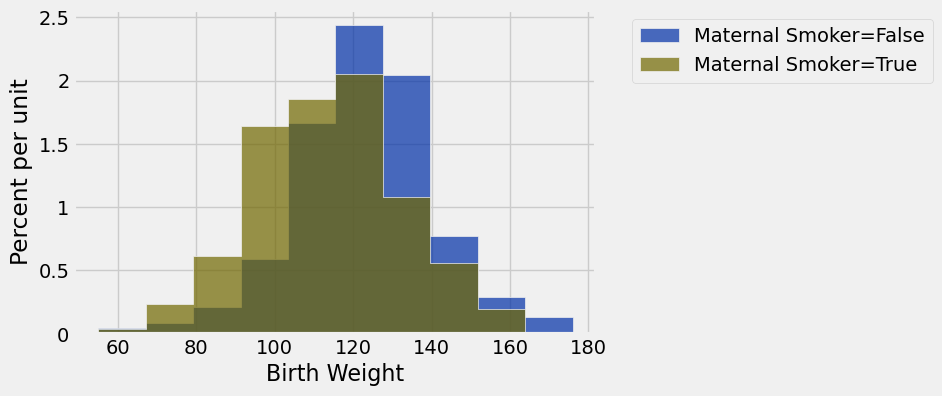

In [6]:
#Display a histogram that displays the birthweight distribution of both groups. 
#Hint: Use the ? to see how to identify the group. 

smoking_and_birthweight.hist(group='Maternal Smoker')

### What question should we be asking?

Give a null and alternative hypothesis for this study.

* **Null:** ?
* **Alternative:** ?


# Test Statistic

* What are our two groups?
* What statistic should we use to test our hypothesis?
* What values of our statistic are in favor of the alternative: positive or negative?

In [7]:
#Create a table that will show the average birth weight for each group. 

means_table = smoking_and_birthweight.group('Maternal Smoker', np.mean)

means_table

Maternal Smoker,Birth Weight mean
False,123.085
True,113.819


In [8]:
#Calculate the difference between averages. 
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [9]:
def difference_of_means(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups"""
    
    #table with the two relevant columns
    reduced = table.select(label, group_label)  
    
    # table containing group means
    means_table = reduced.group(group_label, np.average)
    # array of group means
    means = means_table.column(1)
    
    return means.item(1) - means.item(0)


In [11]:
#Check to make sure our function works. What are the correct inputs?

difference_of_means(births, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

# Random Permutation (Shuffling)

Thought Process: If the null is true, all random rearrangements of the labels are equally likely.
</br></br>
How do we randomly rearrange the rows?


### Example

In [12]:
letters = Table().with_column('Letter', make_array('a', 'b', 'c', 'd', 'e'))
letters

Letter
a
b
c
d
e


In [13]:
letters.sample()

Letter
b
d
b
c
a


In [14]:
#We do not want to increase the number of any of the labels. 
#So replacement is false. 
letters.sample(with_replacement = False)

Letter
c
b
e
a
d


In [15]:
letters.with_column('Shuffled', letters.sample(with_replacement = False).column(0))

Letter,Shuffled
a,c
b,b
c,e
d,d
e,a


# Simulation Under Null Hypothesis

If the null is true, when we rearrange whether the mothers smoked or not it should not greatly affect the average weights.


In [16]:
smoking_and_birthweight

Birth Weight,Maternal Smoker
120,False
113,False
128,True
108,True
136,False
138,False
132,False
120,False
143,True
140,False


In [17]:
shuffled_labels = smoking_and_birthweight.sample(with_replacement=False).column('Maternal Smoker')

In [18]:
original_and_shuffled = smoking_and_birthweight.with_column(
    'Shuffled Label', shuffled_labels
)

In [19]:
original_and_shuffled

Birth Weight,Maternal Smoker,Shuffled Label
120,False,False
113,False,False
128,True,False
108,True,False
136,False,False
138,False,True
132,False,True
120,False,True
143,True,True
140,False,False


In [20]:
# Original Table Group
smoking_and_birthweight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


In [21]:
# Shuffled Table Group, what do you notice?
original_and_shuffled.group('Shuffled Label')

Shuffled Label,count
False,715
True,459


In [22]:
#If the null is true, what do we expect this number to be near?
difference_of_means(original_and_shuffled, 'Birth Weight', 'Shuffled Label')

-1.0420433596904104

In [23]:
#The original difference when labels were accurately assigned.
difference_of_means(original_and_shuffled, 'Birth Weight', 'Maternal Smoker')

-9.266142572024918

Do we have reason to continue our testing? Why or Why not?

# Permutation Test

In [26]:
def one_simulated_difference(table, label, group_label):
    """Takes: name of table, column label of numerical variable,
    column label of group-label variable
    Returns: Difference of means of the two groups after shuffling labels"""
    
    # array of shuffled labels
    shuffled_labels = table.sample(with_replacement = False).column(group_label)
    
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(label).with_column('Shuffled Label', shuffled_labels)
    
    # Uncomment to return the shuffled table
    # return shuffled_table
    
    return difference_of_means(shuffled_table, label, 'Shuffled Label')   

In [27]:
#Run this several times. What do you observe?
smoking_and_shuffled = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
smoking_and_shuffled

2.359921995216112

In [28]:
#Store the differences of many simualations in an array.
differences = make_array()

for i in np.arange(2500):
    new_difference = one_simulated_difference(births, 'Birth Weight', 'Maternal Smoker')
    differences = np.append(differences, new_difference)

In [29]:
#How are we calculating the p-value?

p_value = np.count_nonzero(differences <= observed_difference) / 2500

P-Value: 0.0
Observed Difference: -9.266142572024918


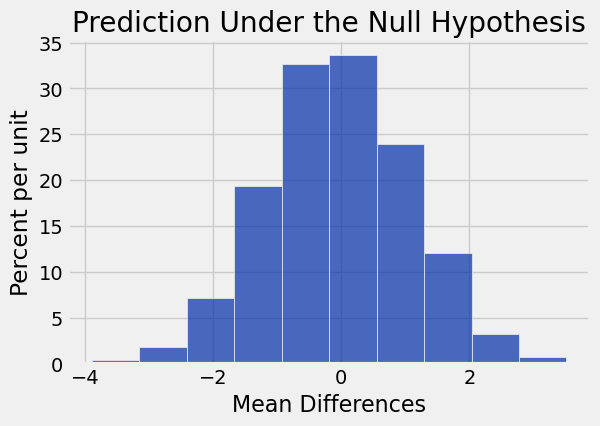

In [30]:
#Create a table that stores the differences. Do not reuse any variable names used above. 

diff_btwn_group_means = Table().with_columns('Mean Differences', differences)

#Display a histogram with the default number of bins that shows the range of the differences.
diff_btwn_group_means.hist()

#This code will display the found p-value, observered difference, and title the histogram.
print('P-Value:', p_value)
print('Observed Difference:', observed_difference)
plots.title('Prediction Under the Null Hypothesis');

Does our data support the null hypothesis or the alternative hypothesis? Why?